# Laplace-Hamming Filter & Segmentation Example 

- **By:** Sarah Elmahdy, 2025 
- **License:** CC-BY 
- **How to cite:** *Specify how you want people to cite this notebook. You can refer to a journal publication or a to repository (to know how to make your code citable by connecting a GitHub repository to Zenodo and get a DOI, read this [blog post](https://docs.github.com/en/repositories/archiving-a-github-repository/referencing-and-citing-content) or watch this [video](https://www.youtube.com/watch?v=gp3D4mf6MHQ))*

---
# Aims

- Demostrate the application of Laplace-Hamming Filter and the segmentation to images.

  **Table of contents**  
  [Step 1: Imports](#imports)   
  [Step 2: Laplace Hamming](#LH)  
  [Step 3: Segmentation of Laplace Hamming Filtered Image](#LHSeg)  

---

<a name="imports"></a>
## *Step 1: Imports:*

Import modules/packages and set the input image path. 

In [18]:
import scipy
import SimpleITK as sitk
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

from scipy.fft import fftshift
from scipy.fft import fftn, ifftn

from ormir_xct.segmentation.gauss_seg import gauss_seg

# image_read no longer exists
from ormir_xct.segmentation.fft_laplace import segmentation_laplace_hamming, fft_laplace_hamming
from ormir_xct.util.file_reader import file_reader

In [19]:
image_file = "images/GRAY_JOINT.nii"
slice_index = 10

image_ipl_file_path = "images/GRAY_JOINT.nii"
peri_ipl_file_path = "images/AUTOCONTOUR_IPL.nii"

<a name="LH"></a>
## *Step 2: Laplace Hamming*

Apply Laplace Hamming filter to the image

In [20]:

# Create array of orginal image
image = sitk.ReadImage(image_file)
image_np = sitk.GetArrayFromImage(image)


In [21]:
# Apply Laplace Hamming filter
filtered_image_np = fft_laplace_hamming(image_np)

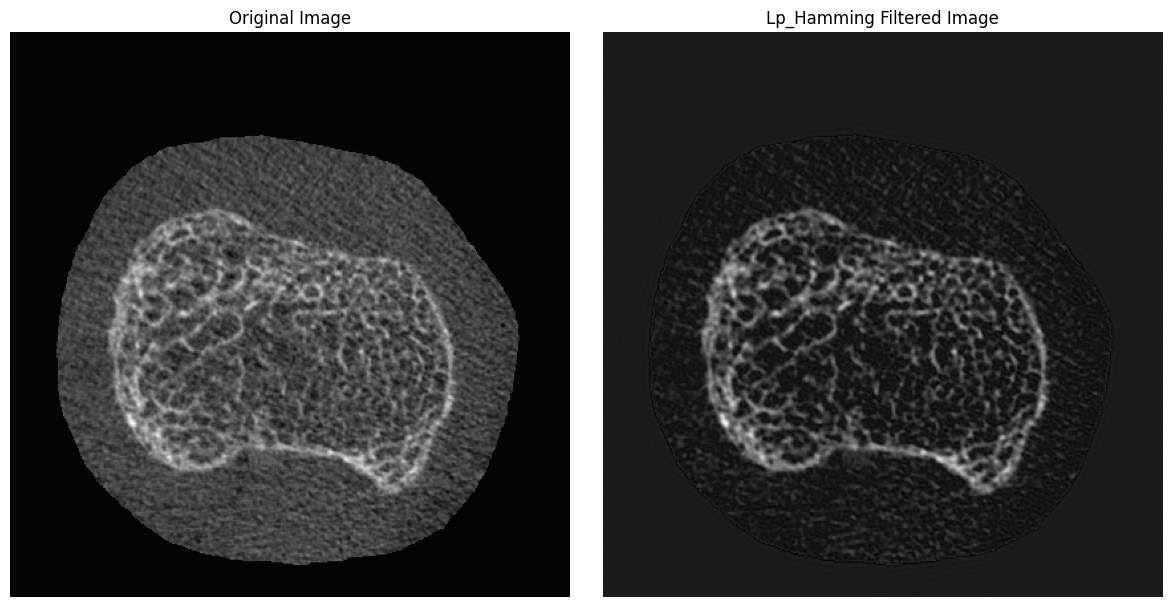

In [22]:
plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(image_np[slice_index, :, :], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(filtered_image_np[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

<a name="LHSeg"></a>
## *Step 3: Segmentation of Laplace Hamming Filtered Image*

Apply segmentation for the Laplace Hamming filter to the image.

In [23]:
# First way is to create the segmented image at the same time with the Laplace Hamming filter
# Can add the lower and upper threshold when calling the function
output = "images/test1.nii"
filtered_segment_image = segmentation_laplace_hamming(image, output)
filtered_segment_image_np = sitk.GetArrayFromImage(filtered_segment_image)

In [24]:
# Other way is to call the segmentation function
# Can add the lower and upper threshold when calling the function
output = "images/test2.nii"
segmented_image = segmentation_laplace_hamming(image, output)
segmented_image = sitk.GetArrayFromImage(segmented_image)

For comparison, will demonstrate IPL standard segmentation on the same image.

In [25]:
image_ipl = sitk.ReadImage(image_ipl_file_path)
peri_ipl = sitk.ReadImage(peri_ipl_file_path)

image_ipl_np = sitk.GetArrayFromImage(image_ipl)
peri_ipl_np = sitk.GetArrayFromImage(peri_ipl)

In [28]:
# not working: size of image_ipl and peri_ipl do not match
# masked = sitk.Mask(image_ipl, peri_ipl) 
ipl_mask = gauss_seg(image_ipl, 1170, 10000)
ipl_mask_np = sitk.GetArrayFromImage(ipl_mask)

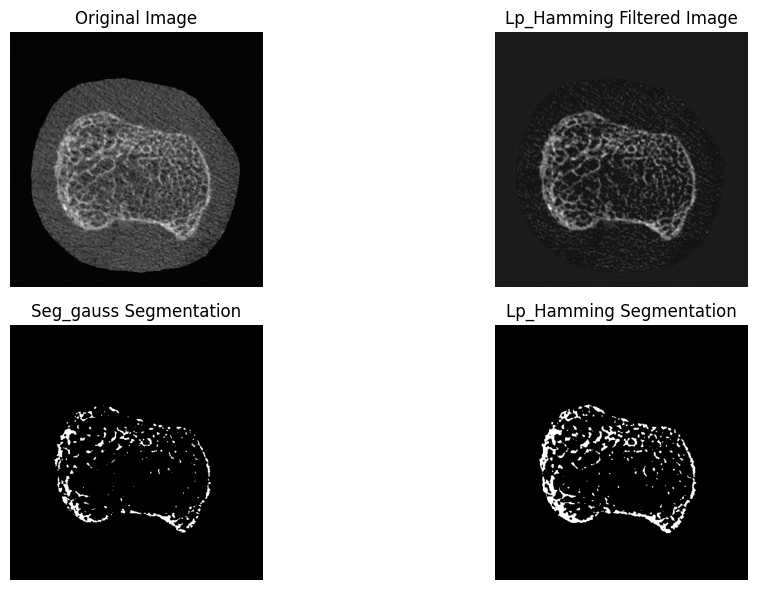

In [30]:
plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(2, 2, 1)
plt.imshow(image_np[slice_index, :, :], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot the laplace Hamming filtered image slice
plt.subplot(2, 2, 2)
plt.imshow(filtered_image_np[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Filtered Image")
plt.axis("off")

# Plot the IPL standard segmentation image slice
plt.subplot(2, 2, 3)
plt.imshow(ipl_mask_np[slice_index, :, :], cmap="gray")
plt.title("Seg_gauss Segmentation")
plt.axis("off")

# Plot the Laplace Hamming segmentation image slice
plt.subplot(2, 2, 4)
plt.imshow(filtered_segment_image_np[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Segmentation")
plt.axis("off")


plt.tight_layout()
plt.show()

---
<a name="attribution"></a>

Notebook created using the [template](https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb) of the [ORMIR community](https://ormircommunity.github.io/) (version 1.0, 2023)